In [1]:
import torch
print(torch.__version__)

2.12.0+cpu


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def create_model():
    net = nn.Sequential(
        nn.Linear(1, 32),
        nn.Tanh(),
        nn.Linear(32, 32),
        nn.Tanh(),
        nn.Linear(32, 32),
        nn.Tanh(),
        nn.Linear(32, 1)
    )
    return net

In [4]:
def double_derivative(model, x):
    x.requires_grad = True
    u = model(x)
    du_dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u_dx2 = torch.autograd.grad(du_dx, x, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0]
    return d2u_dx2

In [5]:
def compute_loss(model, f, x_interior, x_boundary, u_target, lambda_bc):
    d2u_dx2 = double_derivative(model, x_interior)
    res = -d2u_dx2 - f(x_interior)
    L_pde = torch.mean(res**2)
    u_boundary = model(x_boundary)
    L_bc = torch.mean((u_boundary - u_target)**2)
    L_total = L_pde + lambda_bc * L_bc
    return L_total, L_pde.item(), L_bc.item()

In [6]:
def train(model, f, u_left, u_right, epochs=8000, n_collocation=1000, lambda_bc=100, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.9)
    x_boundary = torch.tensor([[0.0], [1.0]], dtype=torch.float32)
    history = {'total_loss': [], 'pde_loss': [], 'bc_loss': []}
    u_target = torch.tensor([[u_left], [u_right]], dtype=torch.float32)
    
    for epoch in range(epochs):
        x_interior = torch.rand((n_collocation, 1), dtype=torch.float32)
        x_interior.requires_grad = True
        
        loss, pde_loss, bc_loss = compute_loss(model, f, x_interior, x_boundary, u_target, lambda_bc)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        history['total_loss'].append(loss.item())
        history['pde_loss'].append(pde_loss)
        history['bc_loss'].append(bc_loss)
        
        if epoch % 1000 == 0:
            print(f"Epoch {epoch}, Total Loss: {loss.item():.6f}, PDE Loss: {pde_loss:.6f}, BC Loss: {bc_loss:.6f}")
            
    return history

In [7]:
def evaluate(model, exact_solution):
    x_test = torch.linspace(0, 1, 100).unsqueeze(1)
    with torch.no_grad():
        u_pred = model(x_test).numpy()
    
    u_exact = exact_solution(x_test).numpy()
    error = np.abs(u_pred - u_exact)
    
    print(f"Max Absolute Error: {np.max(error):.6f}")
    print(f"Mean Absolute Error: {np.mean(error):.6f}")
    print(f"Relative L2 Error: {np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact):.6f}")

    return x_test.numpy(), u_pred, u_exact, error

In [8]:
def plot_results(x_test, u_pred, u_exact, error, history):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    axs[0].plot(x_test, u_exact, label='Exact Solution', color='blue')
    axs[0].plot(x_test, u_pred, label='PINN Prediction', color='red', linestyle='dashed')
    axs[0].set_title('Exact vs PINN Solution')
    axs[0].set_xlabel('x')
    axs[0].legend()

    axs[1].plot(x_test, error, label='Absolute Error', color='green')
    axs[1].set_title('Absolute Error')
    axs[1].set_xlabel('x')
    axs[1].legend()

    axs[2].semilogy(history['total_loss'], label='Total Loss', color='purple')
    axs[2].semilogy(history['pde_loss'], label='PDE Loss', color='orange')
    axs[2].semilogy(history['bc_loss'], label='Boundary Loss', color='cyan')
    axs[2].set_title('Training Loss History')
    axs[2].set_xlabel('Epoch')
    axs[2].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# Problem 1: Standard Sine Wave (Your Original)
# PDE: -u'' = pi^2 * sin(pi*x)
# Exact: u(x) = sin(pi*x)

f = lambda x: (torch.pi**2) * torch.sin(torch.pi * x)
u_left, u_right = 0.0, 0.0
exact = lambda x: torch.sin(torch.pi * x)
problem_name = "Problem 1: Sine Wave"

net = create_model()

history = train(net, f, u_left, u_right, epochs=8000, n_collocation=1000, lambda_bc=100, lr=0.001)
x_test, u_pred, u_ref, error = evaluate(net, exact)

plot_results(x_test, u_pred, u_ref, error, history)

Epoch 0, Total Loss: 54.293606, PDE Loss: 49.715313, BC Loss: 0.045783
Epoch 1000, Total Loss: 0.002087, PDE Loss: 0.001021, BC Loss: 0.000011


Epoch 0, Total Loss: 3.869771, PDE Loss: 3.838355, BC Loss: 0.000314
Epoch 1000, Total Loss: 0.010070, PDE Loss: 0.000924, BC Loss: 0.000091
Epoch 2000, Total Loss: 0.001734, PDE Loss: 0.000493, BC Loss: 0.000012
Epoch 3000, Total Loss: 0.000394, PDE Loss: 0.000390, BC Loss: 0.000000
Epoch 4000, Total Loss: 0.000283, PDE Loss: 0.000279, BC Loss: 0.000000
Epoch 5000, Total Loss: 0.002192, PDE Loss: 0.000226, BC Loss: 0.000020
Epoch 6000, Total Loss: 0.000201, PDE Loss: 0.000195, BC Loss: 0.000000
Epoch 7000, Total Loss: 0.000159, PDE Loss: 0.000159, BC Loss: 0.000000
Max Absolute Error: 0.000827
Mean Absolute Error: 0.000605
Relative L2 Error: 0.003404


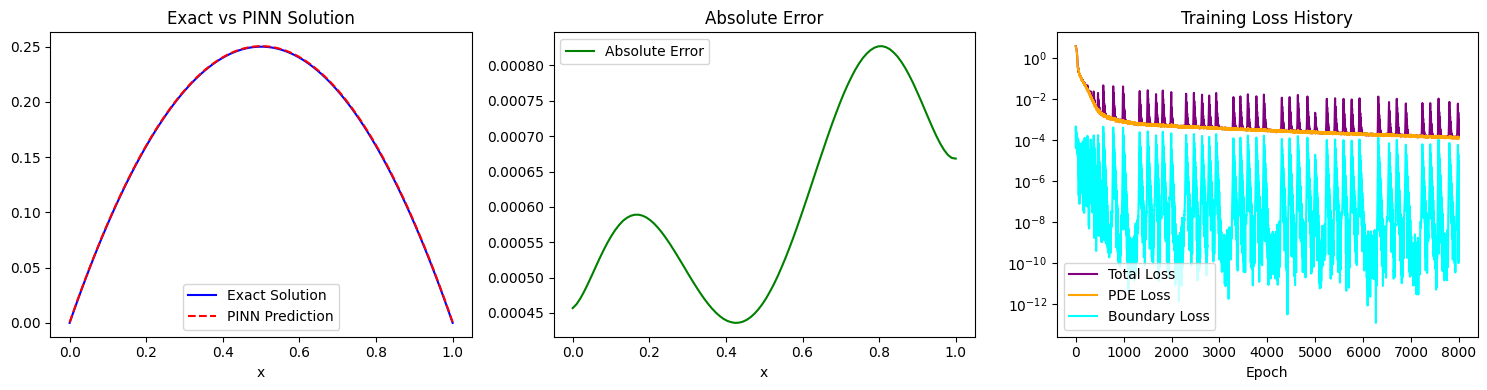

In [ ]:
# Problem 2: Simple Polynomial
# PDE: -u'' = 2
# Exact: u(x) = x * (1 - x)  [or x - x^2]

f = lambda x: 2.0 * torch.ones_like(x)
u_left, u_right = 0.0, 0.0
exact = lambda x: x * (1 - x)
problem_name = "Problem 2: Polynomial"

net = create_model()

history = train(net, f, u_left, u_right, epochs=8000, n_collocation=1000, lambda_bc=100, lr=0.001)
x_test, u_pred, u_ref, error = evaluate(net, exact)

plot_results(x_test, u_pred, u_ref, error, history)

Epoch 0, Total Loss: 804.044617, PDE Loss: 803.921143, BC Loss: 0.001235
Epoch 1000, Total Loss: 0.022169, PDE Loss: 0.021835, BC Loss: 0.000003
Epoch 2000, Total Loss: 0.003812, PDE Loss: 0.003547, BC Loss: 0.000003
Epoch 3000, Total Loss: 0.001292, PDE Loss: 0.001269, BC Loss: 0.000000
Epoch 4000, Total Loss: 0.001089, PDE Loss: 0.000998, BC Loss: 0.000001
Epoch 5000, Total Loss: 0.000919, PDE Loss: 0.000811, BC Loss: 0.000001
Epoch 6000, Total Loss: 0.000478, PDE Loss: 0.000434, BC Loss: 0.000000
Epoch 7000, Total Loss: 0.009964, PDE Loss: 0.007961, BC Loss: 0.000020
Max Absolute Error: 0.001731
Mean Absolute Error: 0.000883
Relative L2 Error: 0.001454


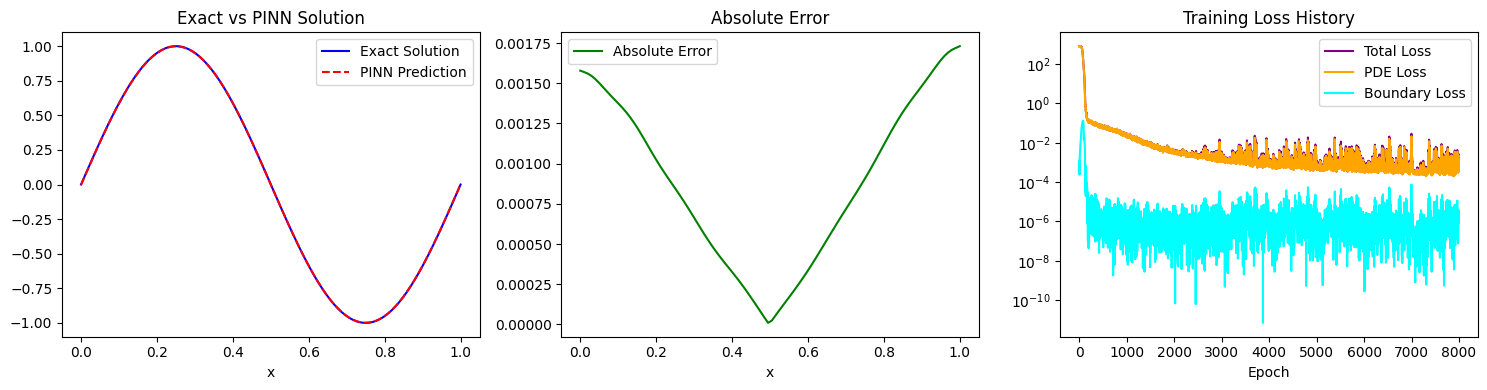

In [ ]:
# Problem 3: Higher Frequency Sine (Harder for PINNs)
# PDE: -u'' = 4*pi^2 * sin(2*pi*x)
# Exact: u(x) = sin(2*pi*x)

f = lambda x: (4 * torch.pi**2) * torch.sin(2 * torch.pi * x)
u_left, u_right = 0.0, 0.0
exact = lambda x: torch.sin(2 * torch.pi * x)
problem_name = "Problem 3: High-Freq Sine"

net = create_model()

history = train(net, f, u_left, u_right, epochs=8000, n_collocation=1000, lambda_bc=100, lr=0.001)
x_test, u_pred, u_ref, error = evaluate(net, exact)

plot_results(x_test, u_pred, u_ref, error, history)

Epoch 0, Total Loss: 380.847107, PDE Loss: 3.079299, BC Loss: 3.777678
Epoch 1000, Total Loss: 0.009068, PDE Loss: 0.009062, BC Loss: 0.000000
Epoch 2000, Total Loss: 0.005052, PDE Loss: 0.005052, BC Loss: 0.000000
Epoch 3000, Total Loss: 0.002485, PDE Loss: 0.002485, BC Loss: 0.000000
Epoch 4000, Total Loss: 0.001099, PDE Loss: 0.001099, BC Loss: 0.000000
Epoch 5000, Total Loss: 0.000350, PDE Loss: 0.000350, BC Loss: 0.000000
Epoch 6000, Total Loss: 0.000105, PDE Loss: 0.000105, BC Loss: 0.000000
Epoch 7000, Total Loss: 0.000088, PDE Loss: 0.000057, BC Loss: 0.000000
Max Absolute Error: 0.000129
Mean Absolute Error: 0.000040
Relative L2 Error: 0.000032


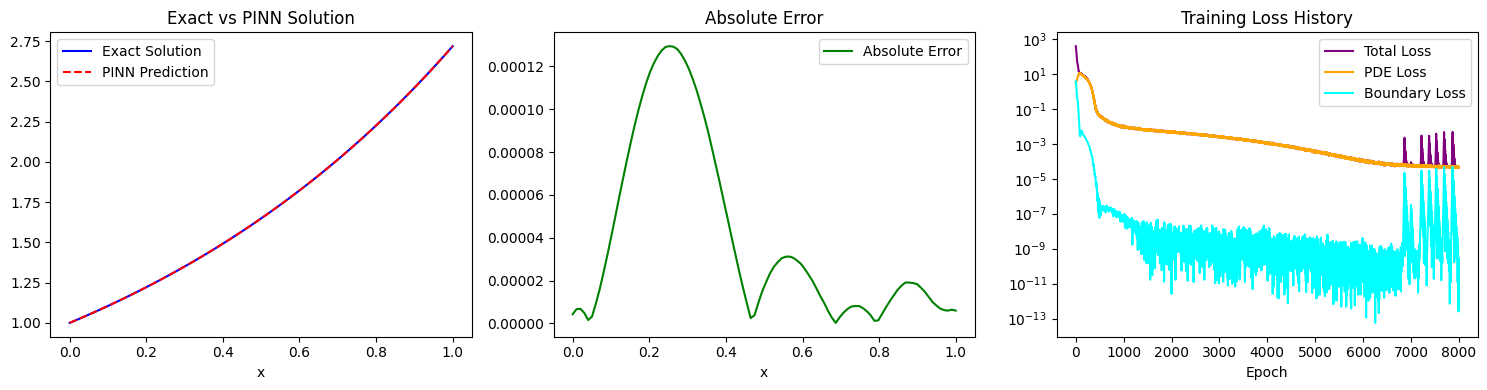

In [ ]:
# Problem 4: Non-Zero Boundary Conditions
# PDE: -u'' = -e^x
# Exact: u(x) = e^x
# Boundary: u(0) = 1, u(1) = e

f = lambda x: -torch.exp(x)
u_left = 1.0 
u_right = torch.exp(torch.tensor(1.0)).item() # approx 2.718
exact = lambda x: torch.exp(x)
problem_name = "Problem 4: Exponential (Non-zero BCs)"

net = create_model()

history = train(net, f, u_left, u_right, epochs=8000, n_collocation=1000, lambda_bc=100, lr=0.001)
x_test, u_pred, u_ref, error = evaluate(net, exact)

plot_results(x_test, u_pred, u_ref, error, history)